# Feature Engineering and Model Training

In [27]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [28]:
df = pd.read_csv("../data/train/data_clean.csv")

# Filter out rows where assessmentClass is "other"
df = df[df['assessmentClass'] != 'other']

# Column type conversion

In [29]:
cat_cols = [
    "assessmentClass",
    "zoning",
    "houseStyle",
    "basement",
    "neighbourhoodName",
    "L_basement2_status",
    "L_basement1_size",
    "L_basement1_status",
]

df = df.drop(columns=["propertyUrl"], errors = "ignore")

# Apply to both train and test dataframes
for col in df.columns:
    if col in cat_cols:
        # Convert specified columns to LightGBM-friendly 'category' type
        df[col] = df[col].astype("category")
    else:
        # Convert all other columns to numeric, forcing errors to NaN
        df[col] = pd.to_numeric(df[col], errors="coerce")

In [30]:
print("Train categorical cols:", df.select_dtypes(include=['category']).columns.tolist())

Train categorical cols: ['assessmentClass', 'zoning', 'houseStyle', 'basement', 'neighbourhoodName', 'L_basement2_status', 'L_basement1_size', 'L_basement1_status']


# Train Test split

In [31]:
df = df.sort_values("closeDate_days").reset_index(drop=True)

n = len(df)

train_end = int(n * 0.7)

train_df = df.iloc[:train_end].copy()
test_df = df.iloc[train_end:].copy()

print(len(train_df), len(test_df))

5263 2256


In [32]:
print(train_df["closeDate_days"][1000])

9483


# Assessment Class

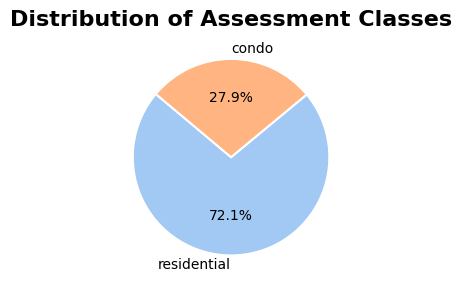

In [33]:
class_counts = df['assessmentClass'].value_counts()

# Plotting
plt.figure(figsize=(3, 3))
colors = sns.color_palette('pastel')[0:len(class_counts)]

plt.pie(
    class_counts, 
    labels=class_counts.index, 
    autopct='%1.1f%%', 
    startangle=140, 
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

plt.title('Distribution of Assessment Classes', fontsize=16, fontweight='bold')
plt.tight_layout()

# livingArea

In [34]:
def plot_boxplot_with_stats(df, column, figsize=(5, 3)):
    """
    Create a boxplot for a numeric column and print summary statistics.
    """

    # Drop missing values
    data = df[column].dropna()

    # Plot boxplot
    plt.figure(figsize=figsize)
    sns.boxplot(x=data)
    plt.title(f"Boxplot of {column}")
    plt.xlabel(column)
    plt.show()

    # Calculate statistics
    stats = {
        "mean": data.mean(),
        "median": data.median(),
        "mode": data.mode().iloc[0] if not data.mode().empty else None,
        "min": data.min(),
        "max": data.max(),
        "q1": data.quantile(0.25),
        "q3": data.quantile(0.75),
    }

    stats["iqr"] = stats["q3"] - stats["q1"]

    # Print statistics
    print(f"Mean: {stats['mean']:.2f}")
    print(f"Median: {stats['median']:.2f}")

    if stats["mode"] is not None:
        print(f"Mode: {stats['mode']:.2f}")
    else:
        print("Mode: None")

    print(f"Min: {stats['min']:.2f}")
    print(f"Max: {stats['max']:.2f}")
    print(f"25th Percentile (Q1): {stats['q1']:.2f}")
    print(f"75th Percentile (Q3): {stats['q3']:.2f}")
    print(f"IQR: {stats['iqr']:.2f}")

    return stats

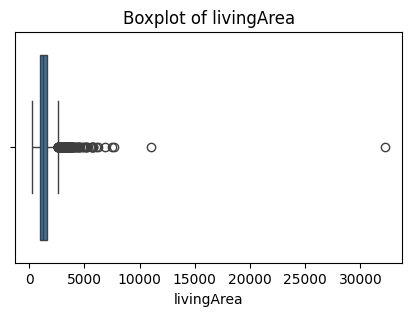

Mean: 1410.49
Median: 1230.00
Mode: 1055.00
Min: 300.00
Max: 32206.00
25th Percentile (Q1): 1023.00
75th Percentile (Q3): 1655.00
IQR: 632.00


In [35]:
livingArea_stats = plot_boxplot_with_stats(train_df, "livingArea")

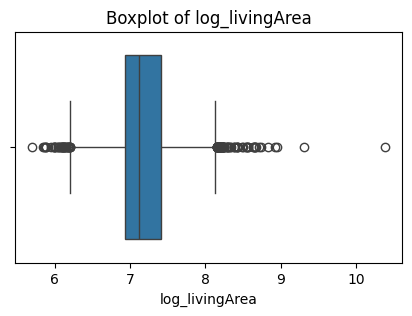

Mean: 7.16
Median: 7.12
Mode: 6.96
Min: 5.71
Max: 10.38
25th Percentile (Q1): 6.93
75th Percentile (Q3): 7.41
IQR: 0.48


In [36]:
train_df['log_livingArea'] = np.log1p(train_df["livingArea"])
test_df['log_livingArea'] = np.log1p(test_df["livingArea"])

livingArea_stats = plot_boxplot_with_stats(train_df, "log_livingArea")

In [37]:
upper_threshold = train_df["log_livingArea"].quantile(1)

train_df = train_df[
    (train_df["log_livingArea"] <= upper_threshold)
].copy()

train_df = train_df.drop(columns=["livingArea"])
test_df = test_df.drop(columns=["livingArea"])

# lotsizeArea

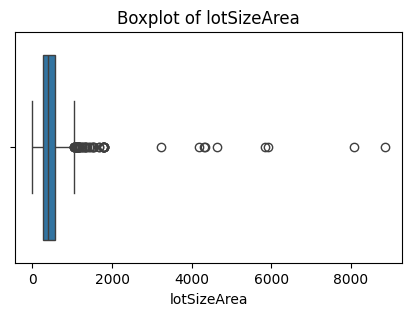

Mean: 428.99
Median: 397.00
Mode: 557.00
Min: 0.00
Max: 8853.00
25th Percentile (Q1): 253.72
75th Percentile (Q3): 569.00
IQR: 315.28


In [38]:
lotSizeArea_stats = plot_boxplot_with_stats(train_df, "lotSizeArea")

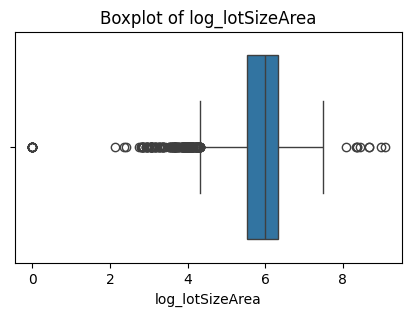

Mean: 5.86
Median: 5.99
Mode: 6.32
Min: 0.00
Max: 9.09
25th Percentile (Q1): 5.54
75th Percentile (Q3): 6.35
IQR: 0.81


In [39]:
train_df['log_lotSizeArea'] = np.log1p(train_df["lotSizeArea"])
test_df['log_lotSizeArea'] = np.log1p(test_df["lotSizeArea"])

lotSizeArea_stats = plot_boxplot_with_stats(train_df, "log_lotSizeArea")

In [40]:
upper_threshold = train_df["log_lotSizeArea"].quantile(1)

train_df = train_df[
    (train_df["log_lotSizeArea"] <= upper_threshold)
].copy()

train_df = train_df.drop(columns=["lotSizeArea"])
test_df = test_df.drop(columns=["lotSizeArea"])

# Price

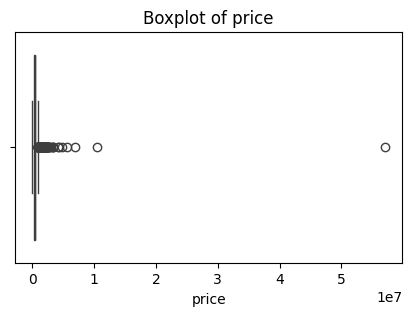

Mean: 441303.16
Median: 400000.00
Mode: 450000.00
Min: 39000.00
Max: 57000000.00
25th Percentile (Q1): 265000.00
75th Percentile (Q3): 510000.00
IQR: 245000.00


In [41]:
price_stats = plot_boxplot_with_stats(train_df, "price")

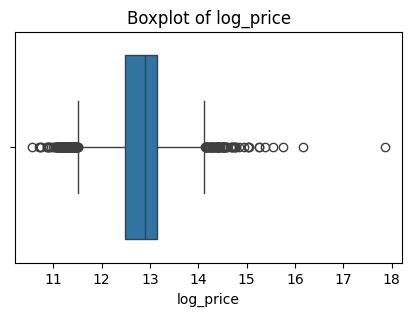

Mean: 12.80
Median: 12.90
Mode: 13.02
Min: 10.57
Max: 17.86
25th Percentile (Q1): 12.49
75th Percentile (Q3): 13.14
IQR: 0.65


In [42]:
train_df['log_price'] = np.log1p(train_df["price"])
test_df['log_price'] = np.log1p(test_df["price"])

price_stats = plot_boxplot_with_stats(train_df, "log_price")

In [43]:
upper_threshold = train_df["log_price"].quantile(1)

train_df = train_df[
    (train_df["price"].notna()) &
    (train_df["price"] > 0) &
    (train_df["log_price"] <= upper_threshold)
].copy()

train_df = train_df.drop(columns=["price"])
test_df = test_df.drop(columns=["price"])

In [44]:
n = len(test_df)

valid_end = int(n * 0.5)

valid_df = test_df.iloc[:valid_end].copy()
test_df = test_df.iloc[valid_end:].copy()

print(len(valid_df), len(test_df))

1128 1128


In [ ]:
y_train = train_df["log_price"]
y_valid = valid_df["log_price"]
y_test = test_df["log_price"]

X_train = train_df.drop(columns=["log_price", "address"])
X_valid = valid_df.drop(columns=["log_price", "address"])
X_test = test_df.drop(columns=["log_price", "address"])

# Train Model

In [46]:
from lightgbm import LGBMRegressor

def make_lgbm(objective="regression", alpha=None):
    params = dict(
        objective=objective,
        n_estimators=300,
        learning_rate=0.05,
        num_leaves=31,
        min_child_samples=25,
        subsample=0.8,
        colsample_bytree=0.8,
        reg_lambda=3.0,
        random_state=42,
        n_jobs=-1,
        verbose=-1,
    )

    if alpha is not None:
        params["alpha"] = alpha

    return LGBMRegressor(**params)


# main model
model_mid = make_lgbm("quantile", alpha=0.50)

# interval models
model_low = make_lgbm("quantile", alpha=0.10)
model_high = make_lgbm("quantile", alpha=0.90)

model_mid.fit(X_train, y_train)
model_low.fit(X_train, y_train)
model_high.fit(X_train, y_train)

print("Models trained!")

Models trained!


In [51]:
def regression_metrics(y_true, y_pred):
    y_pred = np.maximum(y_pred, 1)

    mae = np.mean(np.abs(y_true - y_pred))
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    rmsle = np.sqrt(np.mean((np.log1p(y_true) - np.log1p(y_pred)) ** 2))
    mape = np.mean(np.abs((y_true - y_pred) / np.maximum(y_true, 1))) * 100
    median_ae = np.median(np.abs(y_true - y_pred))

    return {
        "MAE": mae,
        "RMSE": rmse,
        "RMSLE": rmsle,
        "MAPE%": mape,
        "MedianAE": median_ae,
    }

# y_valid_actual = np.expm1(y_valid)
# pred_log = model_mid.predict(X_valid)

y_test_actual = np.expm1(y_test)
pred_log = model_mid.predict(X_test)

pred_price = np.expm1(pred_log)

# regression_metrics(y_valid_actual, pred_price)

regression_metrics(y_test_actual, pred_price)

{'MAE': np.float64(95946.4040182488),
 'RMSE': np.float64(451745.0786291393),
 'RMSLE': np.float64(0.34389368413798416),
 'MAPE%': np.float64(25.145026931409163),
 'MedianAE': np.float64(36148.4226193793)}

# SHAP summary


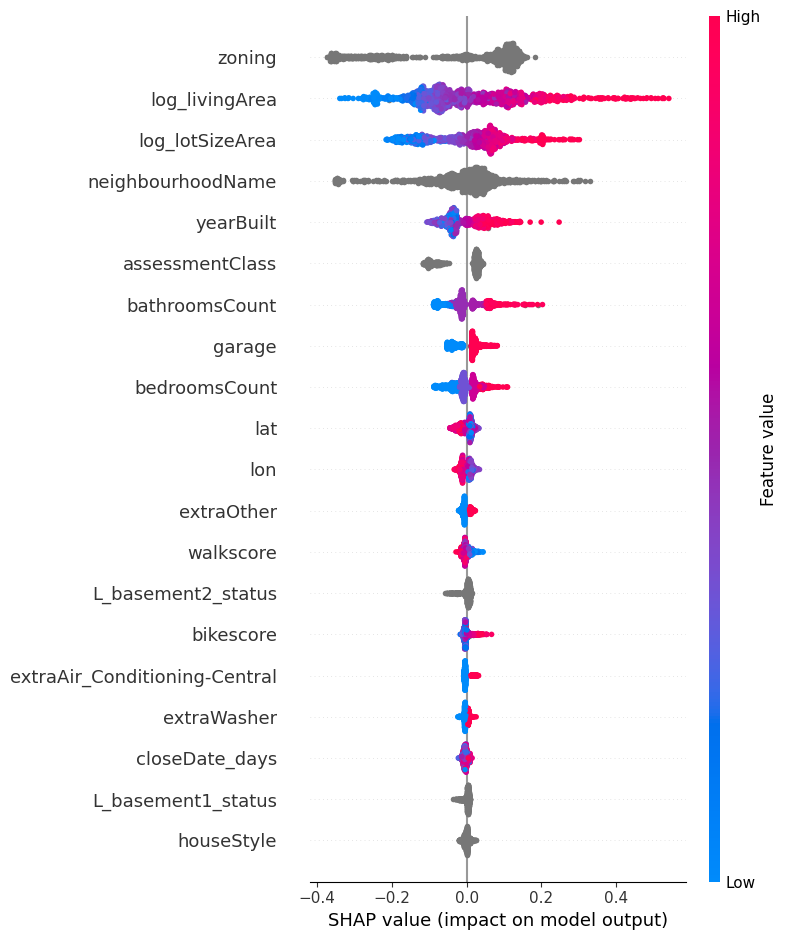

In [48]:
import shap

explainer = shap.TreeExplainer(model_mid)

shap_values = explainer.shap_values(X_test)


shap.summary_plot(
    shap_values,
    X_test
)

In [49]:
test_results = X_test.copy()

test_results["actual"] = y_test
test_results["pred"] = model_mid.predict(X_test)

test_results["abs_error"] = (
    test_results["actual"]
    - test_results["pred"]
).abs()

worst = test_results.sort_values(
    "abs_error",
    ascending=False
)

print(worst.head(30).T)

                                          6513          7222             6557  \
assessmentClass                          condo   residential      residential   
zoning                                     RA7           DC1              RA7   
bathroomsCount                             2.0           NaN              NaN   
bedroomsCount                              2.0           NaN              NaN   
yearBuilt                               2005.0        1930.0           1976.0   
garage                                     0.0           0.0              0.0   
houseStyle                                 NaN           NaN              NaN   
basement                                   NaN           NaN              NaN   
neighbourhoodName              Magrath Heights  Boyle Street  Beverly Heights   
lat                                  53.453423     53.546776        53.568283   
lon                                -113.560646   -113.483956      -113.394379   
L_basement2_status          

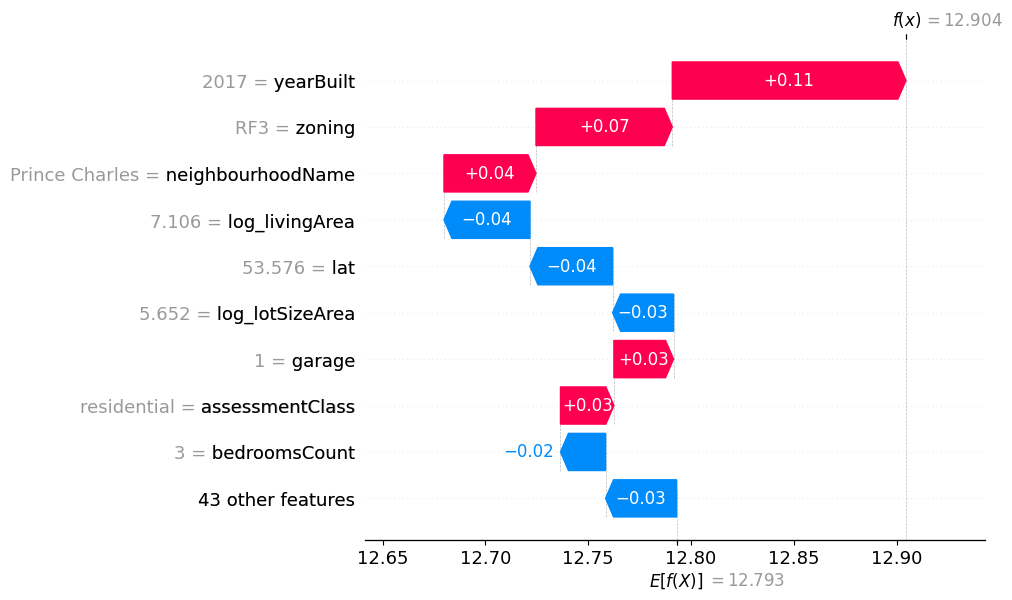

In [50]:
house_idx = 10

shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[house_idx],
        base_values=explainer.expected_value,
        data=X_test.iloc[house_idx],
        feature_names=X_test.columns
    )
)